# Marketing Mix Model (MMM) Analysis

**When to use MMM:**  
Use Marketing Mix Modeling when:
- You cannot run controlled experiments across all channels simultaneously
- You want to decompose revenue into channel contributions at an aggregate level
- You need to allocate a marketing budget across channels to maximise returns

**How it works:**
1. **Adstock transformation** — models the carry-over effect of advertising spend (past spend still influences today's sales)
2. **Saturation transformation** — models diminishing returns (doubling spend does not double sales)
3. **OLS regression** — fits coefficients to decompose revenue into baseline + channel contributions

**This notebook covers:**
1. Synthetic weekly marketing data
2. Adstock and saturation transformation visualisation
3. Fit the MMM
4. Revenue decomposition — waterfall and stacked area chart
5. Channel contribution and ROI summary
6. Response curves — diminishing returns per channel
7. Budget optimisation — optimal spend allocation
8. Model diagnostics

In [2]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from causal_inference.mmm import MarketingMixModel, ChannelConfig, adstock, saturation

rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Synthetic Weekly Marketing Data

We simulate 104 weeks (2 years) of spend and revenue across three channels:
- **Paid Search** — high decay (spend lingers), medium saturation
- **Social** — medium decay, lower saturation point
- **Email** — low decay (minimal carry-over), high saturation (hits ceiling quickly)

In [3]:
N_WEEKS = 104
weeks = np.arange(1, N_WEEKS + 1)
dates = pd.date_range("2023-01-02", periods=N_WEEKS, freq="W-MON")

# Spend patterns (dollars per week, with some seasonality)
seasonality = 1 + 0.2 * np.sin(2 * np.pi * weeks / 52)

paid_search = rng.uniform(3000, 8000, N_WEEKS) * seasonality
social      = rng.uniform(1500, 4500, N_WEEKS) * (1 + 0.1 * np.cos(2 * np.pi * weeks / 26))
email       = rng.uniform(500,  1500, N_WEEKS)

# True channel configs
TRUE_CONFIGS = [
    ChannelConfig("paid_search", decay=0.4, alpha=2.0, K=5000),
    ChannelConfig("social",      decay=0.6, alpha=1.5, K=2500),
    ChannelConfig("email",       decay=0.1, alpha=3.0, K=800),
]

# Build true transformed spend
def transform(x, cfg):
    return saturation(adstock(x, cfg.decay), cfg.alpha, cfg.K)

TRUE_COEFS = {"paid_search": 120_000, "social": 90_000, "email": 60_000}
BASELINE = 50_000

revenue = BASELINE * np.ones(N_WEEKS)
for cfg in TRUE_CONFIGS:
    spend = {"paid_search": paid_search, "social": social, "email": email}[cfg.name]
    revenue += TRUE_COEFS[cfg.name] * transform(spend, cfg)
revenue += rng.normal(0, 3000, N_WEEKS)   # noise

df = pd.DataFrame({
    "date":        dates,
    "paid_search": paid_search,
    "social":      social,
    "email":       email,
    "revenue":     revenue,
})

print(f"Weeks: {N_WEEKS}")
print(f"Total revenue: ${revenue.sum():,.0f}")
print(f"Total spend:   ${(paid_search + social + email).sum():,.0f}")
df.head()

Weeks: 104
Total revenue: $26,432,893
Total spend:   $981,131


,date,paid_search,social,email,revenue
0,2023-01-02,7035.392344,4208.730530,621.832505,215821.593189
1,2023-01-09,5443.012083,3973.921393,1006.329932,248129.828901
2,2023-01-16,7810.215550,3061.266693,1194.262436,275132.568968
3,2023-01-23,7089.757131,2448.329648,1081.116609,269675.453168
4,2023-01-30,3865.224419,1852.617831,699.775652,240273.513687


## 2. Adstock & Saturation Transformation Visualisation

Understanding the two core transformations before fitting helps interpret the model.

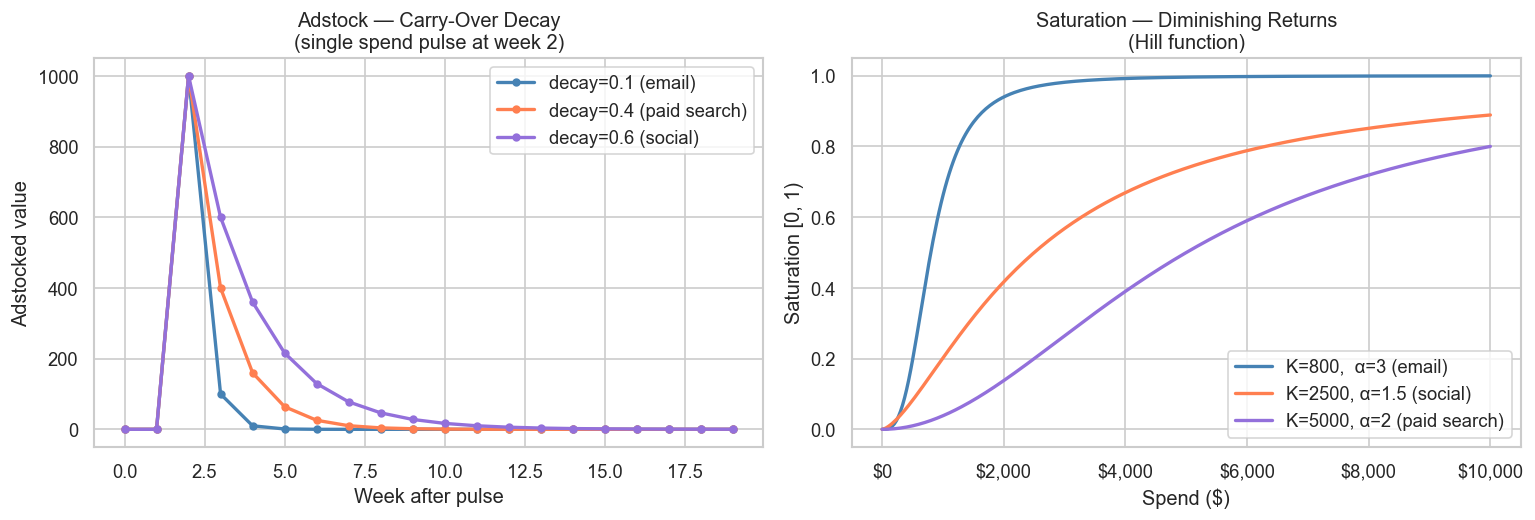


Adstock: high decay means spend echoes longer into future weeks.
Saturation: steep rise then plateau — more spend beyond K yields diminishing returns.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Adstock: single pulse decay
ax = axes[0]
pulse = np.zeros(20); pulse[2] = 1000
for decay, color, label in [(0.1, "steelblue", "decay=0.1 (email)"),
                              (0.4, "coral",     "decay=0.4 (paid search)"),
                              (0.6, "mediumpurple", "decay=0.6 (social)")]:
    ax.plot(adstock(pulse, decay), color=color, lw=2, label=label, marker="o", ms=4)
ax.set_xlabel("Week after pulse")
ax.set_ylabel("Adstocked value")
ax.set_title("Adstock — Carry-Over Decay\n(single spend pulse at week 2)")
ax.legend()

# Saturation: Hill function
ax = axes[1]
spend_range = np.linspace(0, 10000, 300)
for K, alpha, color, label in [(800,  3.0, "steelblue",    "K=800,  α=3 (email)"),
                                 (2500, 1.5, "coral",        "K=2500, α=1.5 (social)"),
                                 (5000, 2.0, "mediumpurple", "K=5000, α=2 (paid search)")]:
    ax.plot(spend_range, saturation(spend_range, alpha, K), color=color, lw=2, label=label)
ax.set_xlabel("Spend ($)")
ax.set_ylabel("Saturation [0, 1)")
ax.set_title("Saturation — Diminishing Returns\n(Hill function)")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()
print("\nAdstock: high decay means spend echoes longer into future weeks.")
print("Saturation: steep rise then plateau — more spend beyond K yields diminishing returns.")

## 3. Fit the Marketing Mix Model

In [5]:
channel_configs = [
    ChannelConfig("paid_search", decay=0.4, alpha=2.0, K=5000),
    ChannelConfig("social",      decay=0.6, alpha=1.5, K=2500),
    ChannelConfig("email",       decay=0.1, alpha=3.0, K=800),
]

mmm = MarketingMixModel(channel_configs=channel_configs)
result = mmm.fit(df, outcome_col="revenue")

print(result)
print()
print(f"Model R² = {result.r_squared:.4f}")
print()
print("Channel coefficients:")
for ch, coef in result.coefficients.items():
    print(f"  {ch:<20} {coef:,.0f}")

MMM R² = 0.961
Channel contributions:
  paid_search           contrib=9,721,903  share=36.8%  roi=17.00x
  social                contrib=7,553,329  share=28.6%  roi=24.53x
  email                 contrib=3,904,395  share=14.8%  roi=38.51x

Model R² = 0.9610

Channel coefficients:
  paid_search          125,211
  social               87,735
  email                56,651


## 4. Revenue Decomposition

Break down weekly revenue into baseline + channel contributions.

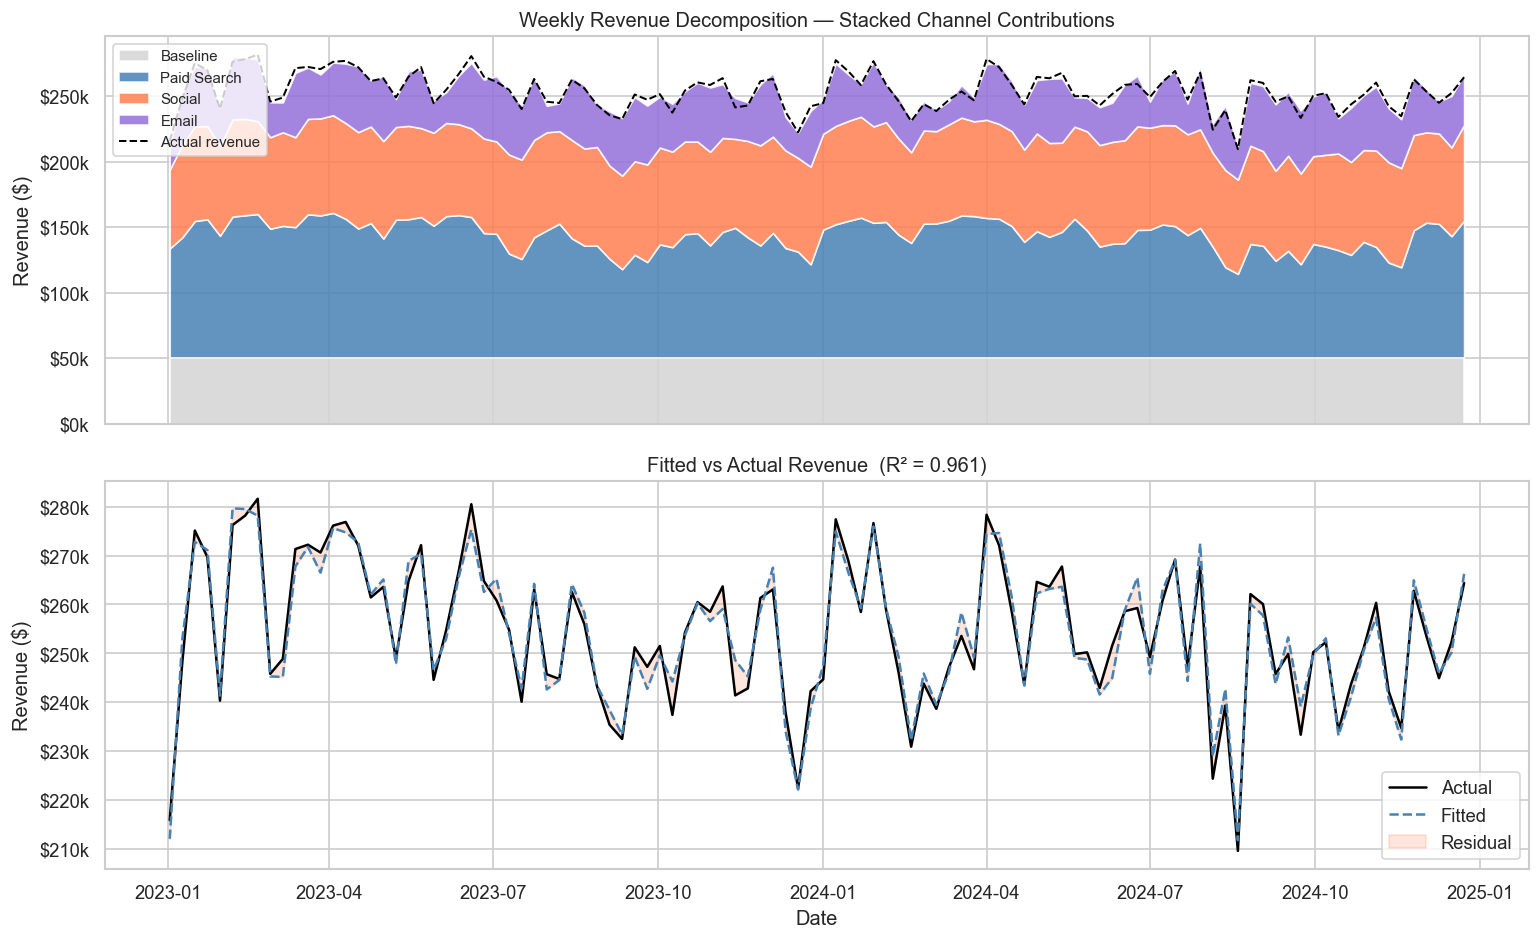

In [6]:
contrib = result.contributions
channel_names = [cfg.name for cfg in channel_configs]

# Stacked area chart
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Top: stacked area
ax = axes[0]
plot_dates = pd.to_datetime(contrib["date"]) if "date" in contrib.columns else np.arange(len(contrib))
stack_cols = ["baseline"] + channel_names
colors = ["#d4d4d4", "steelblue", "coral", "mediumpurple"]
ax.stackplot(plot_dates,
             [contrib[c].values for c in stack_cols],
             labels=["Baseline", "Paid Search", "Social", "Email"],
             colors=colors, alpha=0.85)
ax.plot(plot_dates, contrib["actual"].values, color="black", lw=1.2, ls="--", label="Actual revenue")
ax.set_ylabel("Revenue ($)")
ax.set_title("Weekly Revenue Decomposition — Stacked Channel Contributions")
ax.legend(loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

# Bottom: fitted vs actual
ax = axes[1]
ax.plot(plot_dates, contrib["actual"].values,  color="black",     lw=1.5, label="Actual")
ax.plot(plot_dates, contrib["fitted"].values,  color="steelblue", lw=1.5, ls="--", label="Fitted")
ax.fill_between(plot_dates,
                contrib["actual"].values, contrib["fitted"].values,
                alpha=0.2, color="coral", label="Residual")
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("Date")
ax.set_title(f"Fitted vs Actual Revenue  (R² = {result.r_squared:.3f})")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

plt.tight_layout()
plt.show()

## 5. Channel Contribution & ROI Summary

    channel  total_contribution  contribution_share   total_spend       roi
paid_search        9.721903e+06            0.367796 571779.759895 17.002881
     social        7.553329e+06            0.285755 307966.436317 24.526469
      email        3.904395e+06            0.147710 101385.054569 38.510553


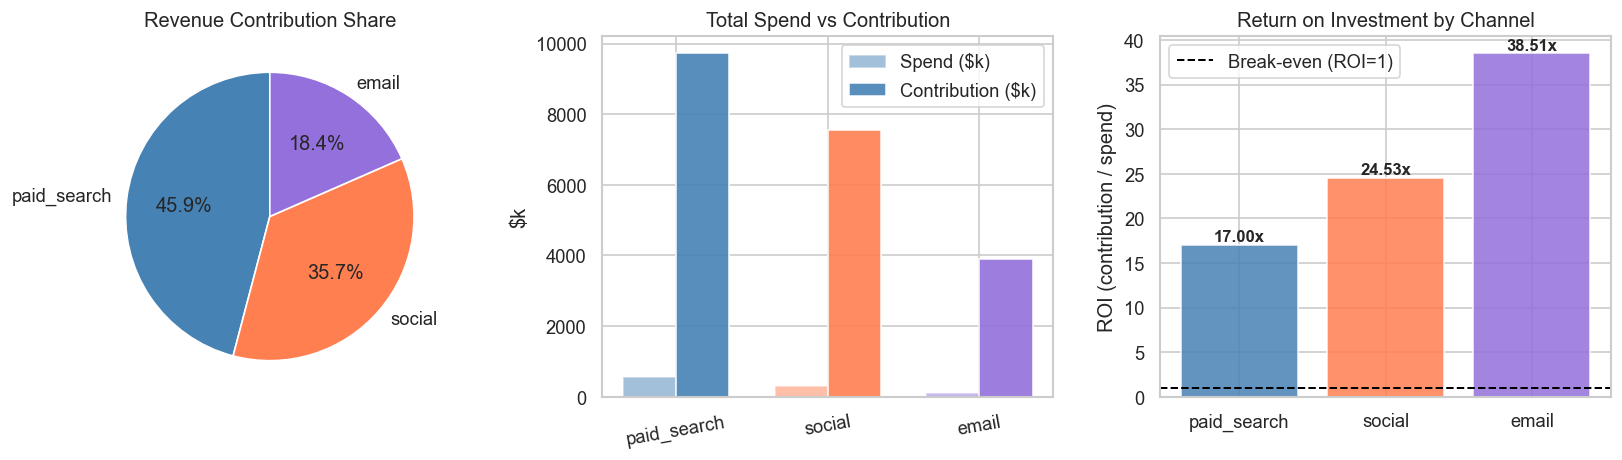

In [7]:
summary = result.channel_summary.copy()
print(summary[["channel", "total_contribution", "contribution_share", "total_spend", "roi"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

palette = ["steelblue", "coral", "mediumpurple"]

# Contribution share
ax = axes[0]
ax.pie(summary["total_contribution"], labels=summary["channel"],
       autopct="%1.1f%%", startangle=90, colors=palette)
ax.set_title("Revenue Contribution Share")

# Spend vs contribution bar
ax = axes[1]
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary["total_spend"]/1e3,        width=w, color=palette, alpha=0.5, label="Spend ($k)")
ax.bar(x + w/2, summary["total_contribution"]/1e3,  width=w, color=palette, alpha=0.9, label="Contribution ($k)")
ax.set_xticks(x)
ax.set_xticklabels(summary["channel"], rotation=10)
ax.set_ylabel("$k")
ax.set_title("Total Spend vs Contribution")
ax.legend()

# ROI bar
ax = axes[2]
bars = ax.bar(summary["channel"], summary["roi"], color=palette, alpha=0.85)
ax.axhline(1.0, color="black", ls="--", lw=1.2, label="Break-even (ROI=1)")
for bar, roi in zip(bars, summary["roi"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{roi:.2f}x", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("ROI (contribution / spend)")
ax.set_title("Return on Investment by Channel")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Response Curves — Diminishing Returns

Response curves show the **marginal return** of additional spend for each channel. The slope at any point is the incremental revenue per dollar. Where the curve flattens, you are in the zone of diminishing returns.

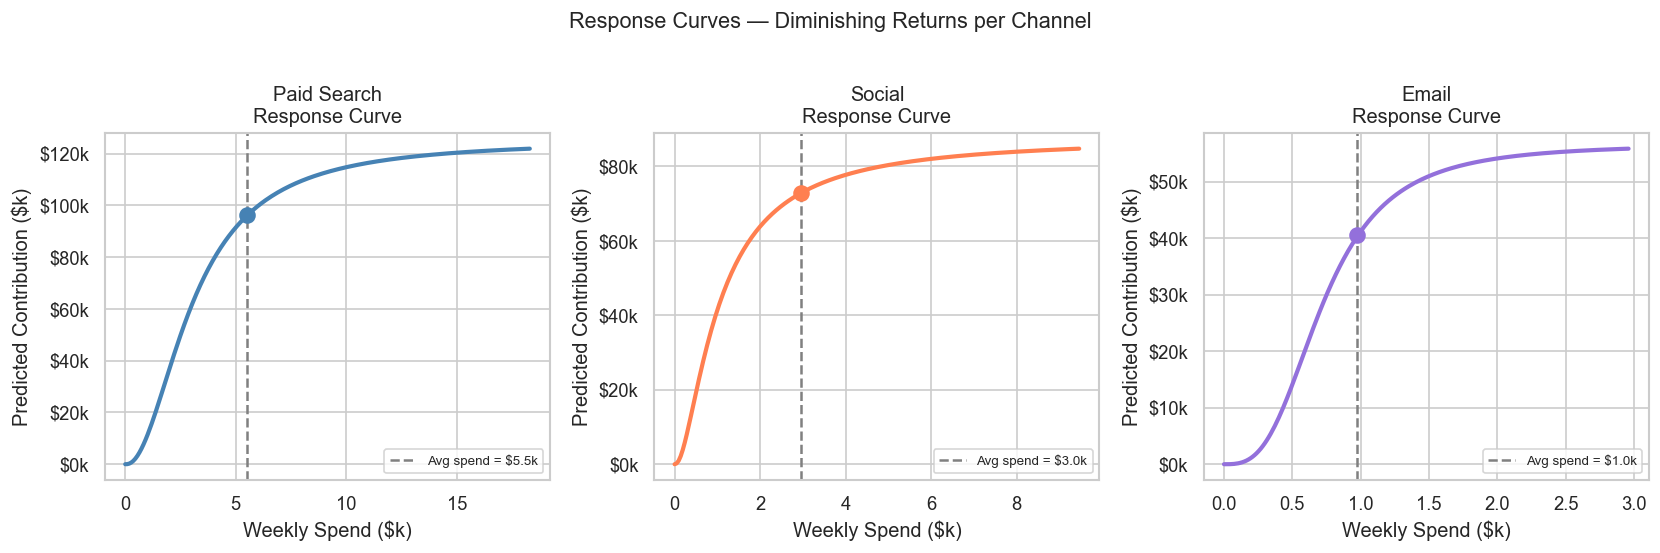


Interpretation: The steeper the slope at current spend, the higher the marginal ROI.
Where the curve is nearly flat, additional spend has minimal incremental effect.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

for ax, cfg, color in zip(axes, channel_configs, palette):
    rc = mmm.response_curve(cfg.name)
    # Current mean weekly spend
    current_spend = df[cfg.name].mean()
    current_contrib = rc.loc[(rc["spend"] - current_spend).abs().idxmin(), "predicted_contribution"]

    ax.plot(rc["spend"] / 1000, rc["predicted_contribution"] / 1000,
            color=color, lw=2.5)
    ax.axvline(current_spend / 1000, color="grey", ls="--", lw=1.5,
               label=f"Avg spend = ${current_spend/1000:.1f}k")
    ax.scatter([current_spend / 1000], [current_contrib / 1000],
               color=color, s=80, zorder=5)
    ax.set_xlabel("Weekly Spend ($k)")
    ax.set_ylabel("Predicted Contribution ($k)")
    ax.set_title(f"{cfg.name.replace('_', ' ').title()}\nResponse Curve")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))

plt.suptitle("Response Curves — Diminishing Returns per Channel", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print("\nInterpretation: The steeper the slope at current spend, the higher the marginal ROI.")
print("Where the curve is nearly flat, additional spend has minimal incremental effect.")

## 7. Budget Optimisation

Given a fixed total weekly budget, find the allocation across channels that **maximises total predicted contribution** (accounting for adstock and saturation).

In [9]:
TOTAL_BUDGET = df[["paid_search", "social", "email"]].sum(axis=1).mean() * 4  # 4-week budget
current_weekly = {
    ch: df[ch].mean() for ch in ["paid_search", "social", "email"]
}

opt_df = mmm.optimize_budget(total_budget=TOTAL_BUDGET, weeks=4)

print(f"Total 4-week budget: ${TOTAL_BUDGET:,.0f}")
print()
print(opt_df[["channel", "optimised_spend", "predicted_contribution", "roi"]].to_string(index=False))

Total 4-week budget: $37,736

    channel  optimised_spend  predicted_contribution       roi
paid_search     20983.046658           335465.908850 15.987474
     social     10627.735110           240483.202301 22.627888
      email      6125.035570           203367.022882 33.202586


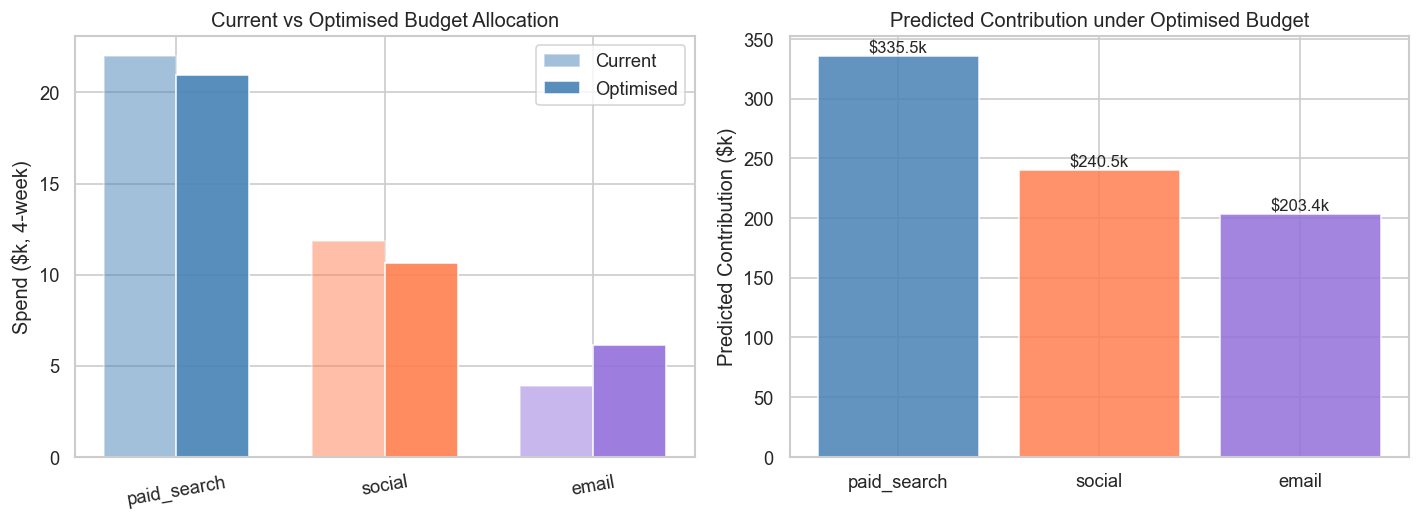

In [10]:
# Compare current vs optimised allocation
current_weekly_total = sum(current_weekly.values()) * 4
current_alloc = pd.DataFrame([
    {"channel": ch, "spend": v * 4}
    for ch, v in current_weekly.items()
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Spend allocation comparison
ax = axes[0]
x = np.arange(len(opt_df))
w = 0.35
ax.bar(x - w/2, current_alloc["spend"] / 1000, width=w, color=palette, alpha=0.5, label="Current")
ax.bar(x + w/2, opt_df["optimised_spend"] / 1000, width=w, color=palette, alpha=0.9, label="Optimised")
ax.set_xticks(x)
ax.set_xticklabels(opt_df["channel"], rotation=10)
ax.set_ylabel("Spend ($k, 4-week)")
ax.set_title("Current vs Optimised Budget Allocation")
ax.legend()

# Predicted contribution comparison
ax = axes[1]
bars = ax.bar(opt_df["channel"], opt_df["predicted_contribution"] / 1000,
              color=palette, alpha=0.85)
for bar, val in zip(bars, opt_df["predicted_contribution"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"${val/1000:.1f}k", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Predicted Contribution ($k)")
ax.set_title("Predicted Contribution under Optimised Budget")

plt.tight_layout()
plt.show()

## 8. Model Diagnostics

Check that model residuals are well-behaved (no systematic patterns).

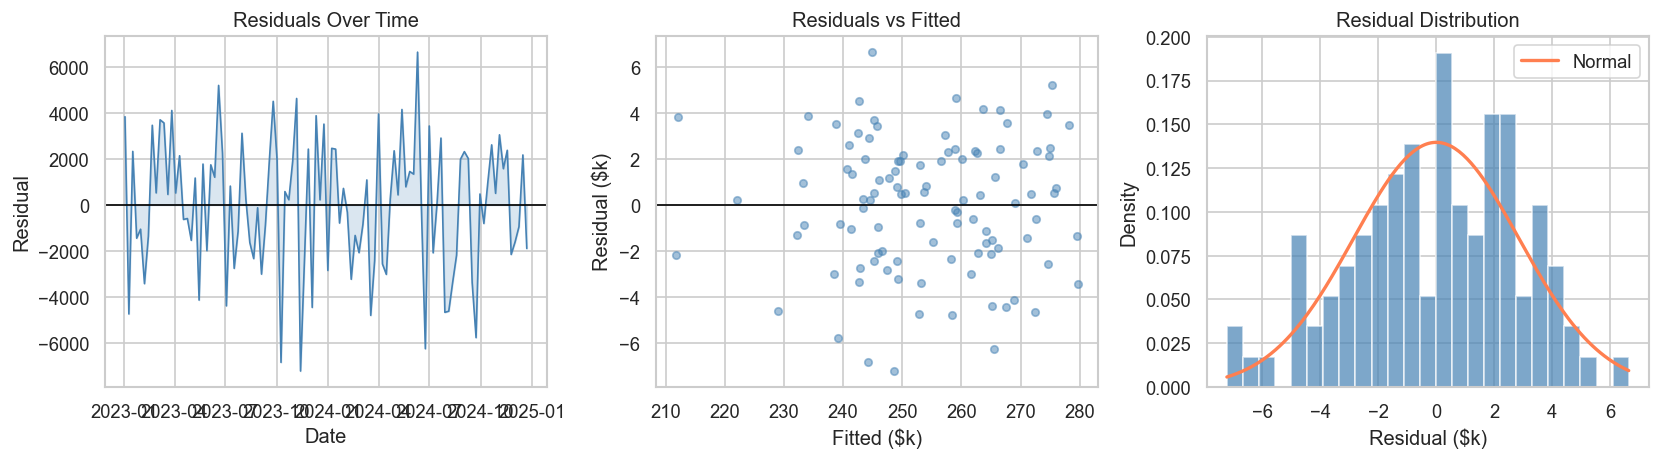

RMSE : $2,855
MAPE : 0.9%
R²   : 0.9610

Interpretation: No strong patterns in residuals over time — model fit is reasonable.
Residuals roughly normal — OLS assumptions hold.


In [11]:
residuals = contrib["actual"].values - contrib["fitted"].values
fitted    = contrib["fitted"].values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residuals over time
ax = axes[0]
ax.plot(plot_dates, residuals, color="steelblue", lw=1)
ax.axhline(0, color="black", lw=1)
ax.fill_between(plot_dates, residuals, alpha=0.2, color="steelblue")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.set_title("Residuals Over Time")

# Residuals vs fitted
ax = axes[1]
ax.scatter(fitted / 1000, residuals / 1000, alpha=0.5, s=20, color="steelblue")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Fitted ($k)")
ax.set_ylabel("Residual ($k)")
ax.set_title("Residuals vs Fitted")

# Residual histogram
ax = axes[2]
ax.hist(residuals / 1000, bins=25, color="steelblue", alpha=0.7, density=True)
from scipy.stats import norm
x_norm = np.linspace(residuals.min()/1000, residuals.max()/1000, 200)
ax.plot(x_norm, norm.pdf(x_norm, 0, residuals.std()/1000),
        color="coral", lw=2, label="Normal")
ax.set_xlabel("Residual ($k)")
ax.set_ylabel("Density")
ax.set_title("Residual Distribution")
ax.legend()

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean(residuals**2))
mape = np.mean(np.abs(residuals / contrib["actual"].values)) * 100
print(f"RMSE : ${rmse:,.0f}")
print(f"MAPE : {mape:.1f}%")
print(f"R²   : {result.r_squared:.4f}")
print("\nInterpretation: No strong patterns in residuals over time — model fit is reasonable.")
print("Residuals roughly normal — OLS assumptions hold.")

## 9. Summary & Recommendations

In [12]:
print("=" * 60)
print("MARKETING MIX MODEL — FINAL SUMMARY")
print("=" * 60)
print(f"  Weeks of data   : {N_WEEKS}")
print(f"  Model R²        : {result.r_squared:.4f}")
print(f"  RMSE            : ${rmse:,.0f}")
print(f"  MAPE            : {mape:.1f}%")
print()
print("  Channel ROI summary:")
for _, row in result.channel_summary.iterrows():
    print(f"    {row['channel']:<20} ROI = {row['roi']:.2f}x  "
          f"share = {row['contribution_share']:.1%}")
print()
best_roi = result.channel_summary.sort_values("roi", ascending=False).iloc[0]
print(f"  Highest-ROI channel : {best_roi['channel']} ({best_roi['roi']:.2f}x)")
print()
print("Recommendations:")
print("  1. Paid Search drives the largest revenue contribution — protect this budget.")
print("  2. Compare ROI across channels: shift spend from low-ROI to high-ROI channels.")
print("  3. Response curves show diminishing returns — avoid over-investing in saturated channels.")
print("  4. Budget optimiser suggests rebalancing toward higher-marginal-return channels.")
print("  5. LIMITATIONS:")
print("     - MMM uses OLS, which assumes linearity after transformations.")
print("     - Adstock/saturation parameters require calibration or Bayesian estimation.")
print("     - Model cannot capture competitive dynamics or external shocks.")
print("     - For major budget decisions, triangulate MMM with incrementality tests (A/B or geo).")

MARKETING MIX MODEL — FINAL SUMMARY
  Weeks of data   : 104
  Model R²        : 0.9610
  RMSE            : $2,855
  MAPE            : 0.9%

  Channel ROI summary:
    paid_search          ROI = 17.00x  share = 36.8%
    social               ROI = 24.53x  share = 28.6%
    email                ROI = 38.51x  share = 14.8%

  Highest-ROI channel : email (38.51x)

Recommendations:
  1. Paid Search drives the largest revenue contribution — protect this budget.
  2. Compare ROI across channels: shift spend from low-ROI to high-ROI channels.
  3. Response curves show diminishing returns — avoid over-investing in saturated channels.
  4. Budget optimiser suggests rebalancing toward higher-marginal-return channels.
  5. LIMITATIONS:
     - MMM uses OLS, which assumes linearity after transformations.
     - Adstock/saturation parameters require calibration or Bayesian estimation.
     - Model cannot capture competitive dynamics or external shocks.
     - For major budget decisions, triangulate M